# DOTK Call-Graph Flamedown (Matplotlib)

This notebook reads the call-graph CSV produced by the language profiler (`/tmp/dotk_callgraph.csv`) and renders a flame-like stacked view using Matplotlib.

Usage:
1. Ensure `/tmp/dotk_callgraph.csv` exists (produced by running the VM with `DOTK_PROFILE=1`).
2. Run the cells below. The final flame image will be written to `/tmp/dotk_flame.png` and displayed inline.

In [1]:
# Install dependencies if needed
# You can skip this cell if pandas/matplotlib are already available in your environment.
%pip install --quiet matplotlib pandas

Note: you may need to restart the kernel to use updated packages.


In [12]:
import pandas as pd
from pathlib import Path

csv_path = Path('/tmp/dotk_callgraph.csv')
if not csv_path.exists():
    raise FileNotFoundError(f"Call-graph CSV not found: {csv_path}")

df = pd.read_csv(csv_path)
df.head()

,caller,callee,call_count,total_ns,avg_ns
0,<root>,lang.k,1,5263,5263
1,bf.k,run,1,112924,112924
2,<root>,bf.k,1,4613278,4613278


In [13]:
from collections import defaultdict
import math

# Build edge table: edges[(caller, callee)] = total_ns
edges = {}
callers = defaultdict(list)
callees = defaultdict(list)

for _, row in df.iterrows():
    caller = str(row['caller'])
    callee = str(row['callee'])
    total_ns = int(row['total_ns'])
    edges[(caller, callee)] = total_ns
    callers[caller].append(callee)
    callees[callee].append(caller)

# Determine the root node name (use '<root>' if present)
ROOT = '<root>' if '<root>' in callers else df['caller'].iloc[0]

# Helper: compute total outgoing time for a node
def node_out_time(node):
    s = 0
    for c in callers.get(node, []):
        s += edges.get((node, c), 0)
    return s

total_root_time = node_out_time(ROOT)
if total_root_time == 0:
    # fallback: sum all edge times
    total_root_time = sum(edges.values())

total_root_time

4618541

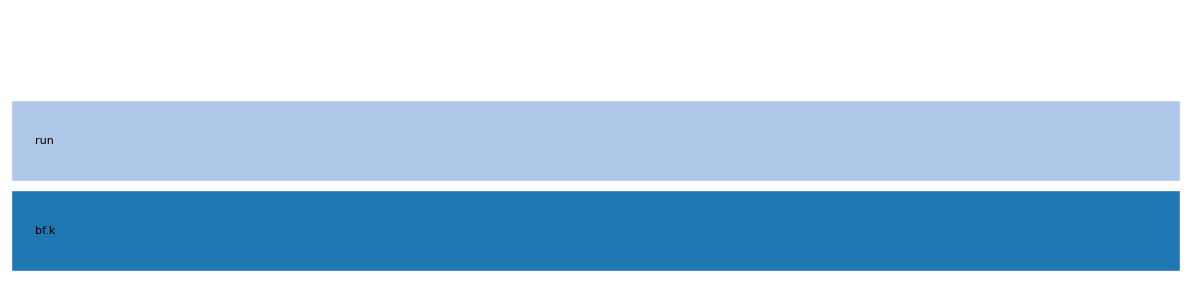

In [18]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from IPython.display import Image, display

fig_w = 12
fig_h = 6
fig, ax = plt.subplots(figsize=(fig_w, fig_h))
ax.set_axis_off()

# Build a layout: recursively place children inside parent's horizontal span.
def layout(node, x, width, depth, max_depth=10, seen=None):
    if seen is None:
        seen = set()
    if node in seen:
        return []
    seen.add(node)
    rects = []
    outs = callers.get(node, [])
    if not outs:
        return []
    out_times = [edges.get((node, c), 0) for c in outs]
    total = sum(out_times)
    if total == 0:
        spans = [width / len(outs)] * len(outs)
    else:
        spans = [width * (t / total) for t in out_times]

    cur_x = x
    for i, c in enumerate(outs):
        w = spans[i]
        rects.append((cur_x, depth, w, 0.8, c))
        rects += layout(c, cur_x, w, depth + 1, max_depth, seen.copy())
        cur_x += w
    return rects

root_x = 0.0
root_w = float(total_root_time)
rects = layout(ROOT, root_x, root_w, 0)

max_depth = 0
for _, d, _, _, _ in rects:
    if d > max_depth:
        max_depth = d

height = max(2, max_depth + 2)
fig.set_size_inches(fig_w, max(3, height * 0.6))

cmap = plt.get_cmap('tab20')
for x, depth, w, h, label in rects:
    if w <= 0:
        continue
    color = cmap((depth % 20) / 20.0)
    ax.add_patch(Rectangle((x, height - depth - 1), w, 0.9, facecolor=color, edgecolor='white'))
    if w > root_w * 0.02:
        ax.text(x + w * 0.02, height - depth - 1 + 0.45, label, va='center', ha='left', fontsize=8, color='black')

ax.set_xlim(0, root_w)
ax.set_ylim(0, height)
ax.invert_yaxis()
plt.tight_layout()
png_path = '/tmp/dotk_flame.png'
# plt.savefig(png_path, dpi=150)

# plt.close(fig)
# display(Image(png_path))
# print('Wrote flame image to', png_path)

In [16]:
# Export folded-stack traces for flamegraph.pl (stack counts use a scaling factor)
import pandas as pd
from pathlib import Path

csv_path = Path('/tmp/dotk_callgraph.csv')
if not csv_path.exists():
    raise FileNotFoundError(f'Call-graph CSV not found: {csv_path}')

df = pd.read_csv(csv_path)
out_path = Path('/tmp/dotk_folded.txt')
# scale_ns controls how many nanoseconds constitute one sample; adjust to taste
scale_ns = 100000  # 100k ns (~0.1ms) per sample
lines = []
for _, r in df.iterrows():
    caller = str(r['caller'])
    callee = str(r['callee'])
    total_ns = int(r['total_ns'])
    count = max(1, int(total_ns / scale_ns))
    # Build a folded stack string: caller;callee (omit <root> as caller)
    if caller == '<root>' or caller.lower() == 'nan':
        stack = f'{callee}'
    else:
        stack = f'{caller};{callee}'
    lines.append(f'{stack} {count}\n')

out_path.write_text(''.join(lines))
print('Wrote folded stacks to', out_path)
print('Example lines:')
print(''.join(lines[:10]))

Wrote folded stacks to /tmp/dotk_folded.txt
Example lines:
lang.k 1
bf.k;run 1
bf.k 46



Notes:
- This simple flamedown builds widths from aggregated `total_ns` on caller→callee edges and lays out callees inside their caller's horizontal span.
- For more accurate flamegraphs, you can produce folded-stack samples (one stack string per sample) and feed them to flamegraph tools; I can add an export step that writes folded stacks if you prefer.
- If your call graph contains cycles, the layout uses a `seen` set to avoid infinite recursion; visual results in cycles may be approximate.